# Online Retail — Exploratory Data Analysis

**Dataset:** UCI Online Retail — ~540k transactions from a UK online retailer
(Dec 2010 – Dec 2011).

**Goal:** understand the shape of retail sales data before building the
`sales-forecaster` project: revenue trends, top products, and what a daily
sales time series looks like.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent / "scripts"))
from download_data import download

df = pd.read_csv(download(), parse_dates=["InvoiceDate"])
df.head()

Already cached: C:\Users\njung\source\repos\data-science-notebooks\data\online_retail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data quality check

In [2]:
print(df.shape)
print(df.isna().sum())
print(f"Cancelled invoices: {(df['InvoiceNo'].astype(str).str.startswith('C')).sum():,}")
print(f"Non-positive quantity rows: {(df['Quantity'] <= 0).sum():,}")

(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Cancelled invoices: 9,288
Non-positive quantity rows: 10,624


Cancellations (invoice numbers starting with "C") and non-positive quantities
are returns/adjustments — exclude them for sales analysis. Missing
`CustomerID` is fine here since we analyse at transaction level, not customer
level.

In [3]:
sales = df[
    (~df["InvoiceNo"].astype(str).str.startswith("C")) & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)
].copy()
sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]
print(f"Clean sales rows: {len(sales):,}")

Clean sales rows: 530,104


## Monthly revenue

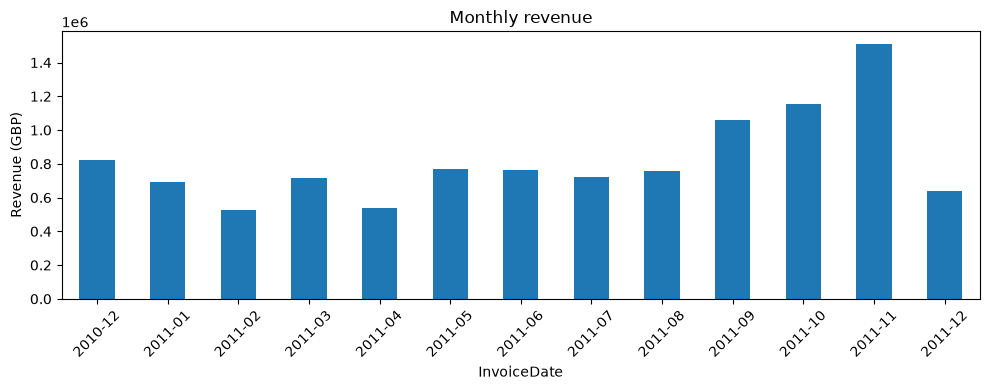

In [4]:
monthly = sales.set_index("InvoiceDate")["Revenue"].resample("ME").sum()
ax = monthly.plot(kind="bar", figsize=(10, 4), title="Monthly revenue")
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly.index], rotation=45)
ax.set_ylabel("Revenue (GBP)")
plt.tight_layout()

## Top 10 products by revenue

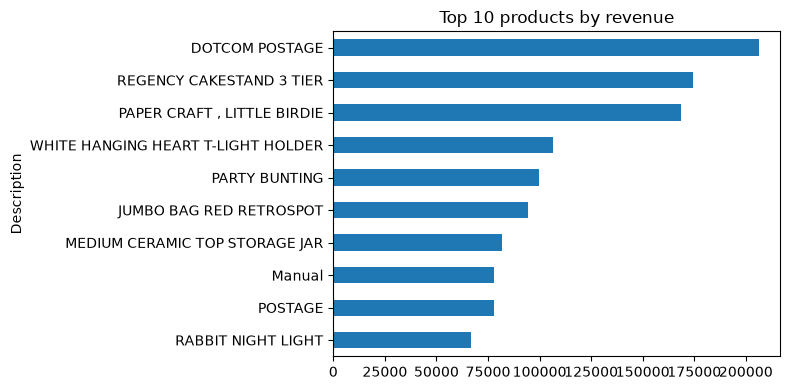

In [5]:
top10 = sales.groupby("Description")["Revenue"].sum().nlargest(10)
top10.sort_values().plot(kind="barh", figsize=(8, 4), title="Top 10 products by revenue")
plt.tight_layout()

## Daily revenue — the forecasting target

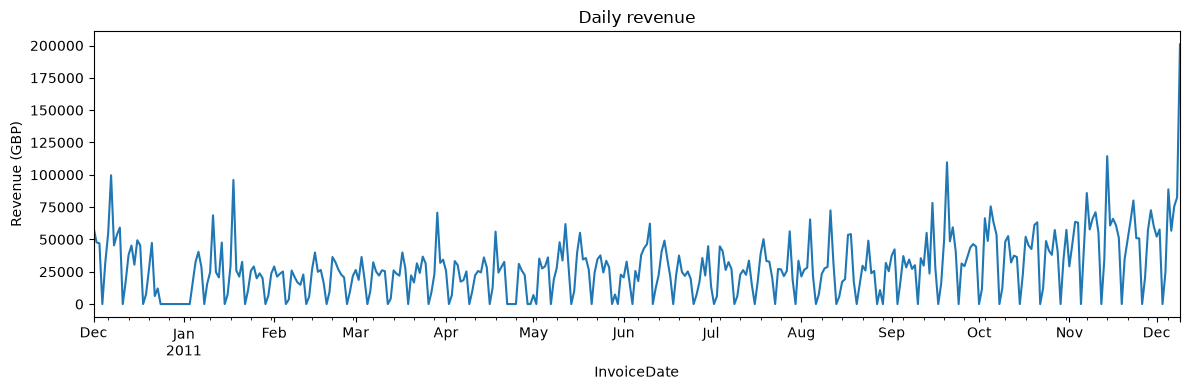

In [6]:
daily = sales.set_index("InvoiceDate")["Revenue"].resample("D").sum()
ax = daily.plot(figsize=(12, 4), title="Daily revenue")
ax.set_ylabel("Revenue (GBP)")
plt.tight_layout()

In [7]:
print(f"Days in series: {len(daily)}")
print(f"Zero-revenue days: {(daily == 0).sum()} (store closed, e.g. Saturdays)")
print(daily.describe().round(0))

Days in series: 374
Zero-revenue days: 69 (store closed, e.g. Saturdays)
count       374.0
mean      28521.0
std       23408.0
min           0.0
25%       12142.0
50%       25974.0
75%       39898.0
max      200921.0
Name: Revenue, dtype: float64


## Takeaways for sales-forecaster

1. **Strong trend + seasonality:** revenue climbs sharply toward
   November–December (holiday shopping) — a forecasting model must capture
   yearly seasonality and trend, not just recent averages.
2. **Weekly pattern with closed days:** zero-revenue days are structural
   (store closed), not noise — the forecaster should model day-of-week
   effects or exclude closed days.
3. **Data cleaning matters:** ~2% of rows are cancellations/adjustments that
   would distort revenue if left in. Phase 1 of sales-forecaster needs the
   same invoice-level cleaning step.